# Customer Retention Analysis using Python

## Project Objective

The objective of this project is to perform exploratory data analysis (EDA) on a customer retention dataset before storing the data in SQL Server and building an interactive Power BI dashboard.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL Server
- Power BI

## Python Tasks Performed

- Load customer datasets
- Inspect data quality
- Validate data types
- Check missing values
- Identify duplicate records
- Generate descriptive statistics
- Perform exploratory data analysis
- Create business insights

## 1. Import Required Libraries

Import the Python libraries required for data loading, data manipulation, and visualization.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Datasets

Load all project datasets into Pandas DataFrames.

In [26]:
customer = pd.read_csv(
    r"C:\Users\lav chauhan\OneDrive\Desktop\Chhavi\SQL_CustomerRetentionProject\csv files\Customer_SQL.csv"
)

subscription = pd.read_csv(
    r"C:\Users\lav chauhan\OneDrive\Desktop\Chhavi\SQL_CustomerRetentionProject\csv files\Subscription_SQL.csv"
)

revenue = pd.read_csv(
    r"C:\Users\lav chauhan\OneDrive\Desktop\Chhavi\SQL_CustomerRetentionProject\csv files\Revenue_SQL.csv"
)

retention = pd.read_csv(
    r"C:\Users\lav chauhan\OneDrive\Desktop\Chhavi\SQL_CustomerRetentionProject\csv files\Retention_SQL.csv"
)

satisfaction = pd.read_csv(
    r"C:\Users\lav chauhan\OneDrive\Desktop\Chhavi\SQL_CustomerRetentionProject\csv files\CustomerSatisfaction_SQL.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 3. Verify Dataset Loading

Display the dimensions of each dataset to ensure the files have been loaded correctly.

In [27]:
datasets = {
    "Customer": customer,
    "Subscription": subscription,
    "Revenue": revenue,
    "Retention": retention,
    "Satisfaction": satisfaction
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Customer: (7043, 11)
Subscription: (7043, 8)
Revenue: (7043, 7)
Retention: (7043, 9)
Satisfaction: (7043, 4)


## 4. Data Understanding

Before performing any analysis, it is important to understand the structure of the dataset.

This includes:
- Viewing sample records
- Understanding the number of rows and columns
- Inspecting column names
- Checking data types
- Generating summary statistics

These checks help identify potential data quality issues before analysis.

In [28]:
customer.head()

,Customer ID,Gender,Age,Senior Citizen,Married,Dependents,State,City,Latitude,Longitude,Population
0,8779-QRDMV,Male,78,Yes,No,No,California,Los Angeles,34.023810,-118.156582,68701
1,7495-OOKFY,Female,74,Yes,Yes,Yes,California,Los Angeles,34.044271,-118.185237,55668
2,1658-BYGOY,Male,71,Yes,No,Yes,California,Los Angeles,34.108833,-118.229715,47534
3,4598-XLKNJ,Female,78,Yes,Yes,Yes,California,Inglewood,33.936291,-118.332639,27778
4,4846-WHAFZ,Female,80,Yes,Yes,Yes,California,Whittier,33.972119,-118.020188,26265


In [29]:
customer.tail()

,Customer ID,Gender,Age,Senior Citizen,Married,Dependents,State,City,Latitude,Longitude,Population
7038,2569-WGERO,Female,30,No,No,No,California,Landers,34.341737,-116.539416,2182
7039,6840-RESVB,Male,38,No,Yes,Yes,California,Adelanto,34.667815,-117.536183,18980
7040,2234-XADUH,Female,30,No,Yes,Yes,California,Amboy,34.559882,-115.637164,42
7041,4801-JZAZL,Female,32,No,Yes,Yes,California,Angelus Oaks,34.167800,-116.864330,301
7042,3186-AJIEK,Male,44,No,No,No,California,Apple Valley,34.424926,-117.184503,28819


In [30]:
customer.shape

(7043, 11)

In [31]:
customer.columns

Index(['Customer ID', 'Gender', 'Age', 'Senior Citizen', 'Married',
       'Dependents', 'State', 'City', 'Latitude', 'Longitude', 'Population'],
      dtype='str')

In [32]:
customer.dtypes

Customer ID           str
Gender                str
Age                 int64
Senior Citizen        str
Married               str
Dependents            str
State                 str
City                  str
Latitude          float64
Longitude         float64
Population          int64
dtype: object

In [33]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer ID     7043 non-null   str    
 1   Gender          7043 non-null   str    
 2   Age             7043 non-null   int64  
 3   Senior Citizen  7043 non-null   str    
 4   Married         7043 non-null   str    
 5   Dependents      7043 non-null   str    
 6   State           7043 non-null   str    
 7   City            7043 non-null   str    
 8   Latitude        7043 non-null   float64
 9   Longitude       7043 non-null   float64
 10  Population      7043 non-null   int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 605.4 KB


In [34]:
customer.describe()

,Age,Latitude,Longitude,Population
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,36.197455,-119.756684,22139.603294
std,16.750352,2.468929,2.154425,21152.392837
min,19.000000,32.555828,-124.301372,11.000000
25%,32.000000,33.990646,-121.788090,2344.000000
50%,46.000000,36.205465,-119.595293,17554.000000
75%,60.000000,38.161321,-117.969795,36125.000000
max,80.000000,41.962127,-114.192901,105285.000000


## 5. Data Quality Assessment

Data quality assessment is performed to identify potential issues before analysis.

The following checks are performed:

- Missing values
- Duplicate records
- Unique values
- Distinct value counts
- Frequency distribution of categorical variables

In [35]:
customer.isnull().sum()

Customer ID       0
Gender            0
Age               0
Senior Citizen    0
Married           0
Dependents        0
State             0
City              0
Latitude          0
Longitude         0
Population        0
dtype: int64

In [36]:
customer.duplicated().sum()

np.int64(0)

In [37]:
customer["Customer ID"].nunique()

7043

In [38]:
customer["Gender"].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [39]:
customer["Senior Citizen"].value_counts()

Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

In [40]:
customer["State"].nunique()

1

In [41]:
customer["City"].value_counts().head(10)

City
Los Angeles      293
San Diego        285
San Jose         112
Sacramento       108
San Francisco    104
Fresno            61
Long Beach        60
Oakland           52
Escondido         51
Stockton          44
Name: count, dtype: int64

# 6. Exploratory Data Analysis

The objective of this section is to identify important customer patterns and generate business insights using Python.

In [42]:
customer["Age"].mean()

np.float64(46.50972596904728)

In [43]:
customer.groupby("Gender")["Age"].mean()

Gender
Female    46.472764
Male      46.545992
Name: Age, dtype: float64

In [44]:
customer["Married"].value_counts()

Married
No     3641
Yes    3402
Name: count, dtype: int64

In [45]:
customer["State"].value_counts()

State
California    7043
Name: count, dtype: int64

# 7. Data Visualization

Data visualization helps transform numerical summaries into visual insights, making it easier to identify patterns, trends, and distributions within the dataset.

The visualizations in this section focus on key customer demographics and characteristics that support the Customer Retention Analysis.

### Objectives

- Visualize customer distribution by gender.
- Analyze the distribution of senior citizens.
- Understand the age distribution of customers.
- Support business insights with graphical representations.

### 7.1 Customer Distribution by Gender

This visualization shows the number of customers across different gender categories and helps identify whether the customer base is balanced.

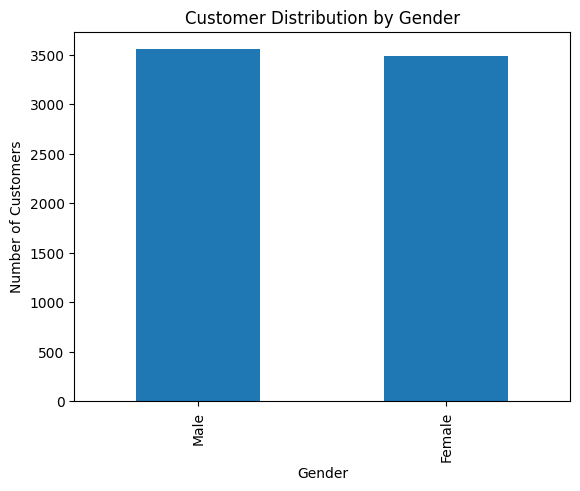

In [46]:
customer["Gender"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### 7.2 Senior Citizen Distribution

This chart displays the number of senior citizen and non-senior citizen customers, helping understand the age-based composition of the customer base.

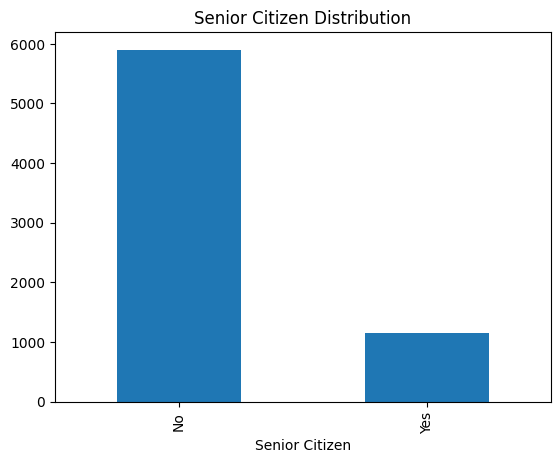

In [47]:
customer["Senior Citizen"].value_counts().plot(kind="bar")

plt.title("Senior Citizen Distribution")

plt.show()

### 7.3 Customer Age Distribution

The histogram illustrates the distribution of customer ages, helping identify common age groups and the spread of the customer population.

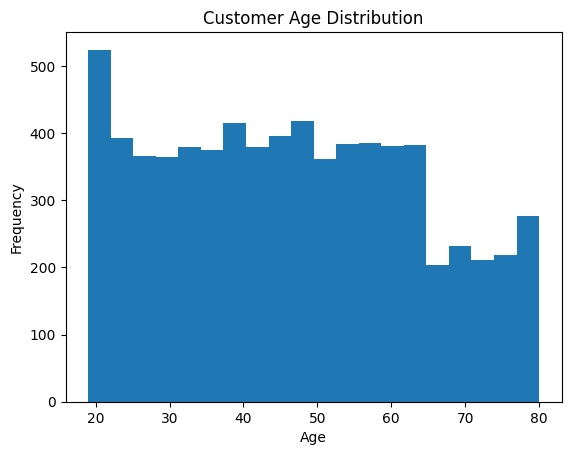

In [48]:
customer["Age"].plot(kind="hist", bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")

plt.show()

# 9. Key Takeaways

Based on the exploratory analysis performed in Python:

- The dataset contains high-quality data with no duplicate customer records.
- Customer demographic information is well distributed across multiple cities.
- Gender distribution is relatively balanced.
- The customer base consists primarily of non-senior citizens.
- The age distribution indicates multiple customer segments, supporting the need for customer segmentation in retention analysis.

The insights generated during the Python analysis complement the SQL-based analytical queries and the interactive Power BI dashboard, providing a complete end-to-end customer retention analytics solution.

# 9. Project Workflow

The complete analytics workflow for this project is shown below:

Raw Excel / CSV Files
        ↓
Python
• Data Loading
• Data Quality Assessment
• Exploratory Data Analysis
        ↓
SQL Server
• Database Creation
• Dimension & Fact Tables
• Data Validation
• Business Analysis Queries
        ↓
Power BI
• Data Modeling
• DAX Measures
• Interactive Dashboard
• Business Insights

# Conclusion

Python was used for:

• Loading customer datasets

• Data quality assessment

• Exploratory Data Analysis (EDA)

• Basic visualization

The cleaned and validated datasets were subsequently analysed in SQL Server and visualized using Power BI to build an interactive Customer Retention Dashboard.

# Future Enhancements

Potential improvements for this project include:

- Automating the data loading process using Python.
- Connecting Power BI directly to SQL Server instead of CSV files.
- Scheduling automated data refreshes.
- Expanding the analysis with customer segmentation and predictive churn modeling.